In [2]:
from brick2221.analysis.analysis_setup import basepath

/blue/adamginsburg/adamginsburg/jwst/brick-jwst-2221/brick2221/reduction/filtering.py:29: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
Set DATE-AVG to '2022-08-28T03:05:32.473' from MJD-AVG.
Set DATE-END to '2022-08-28T03:34:03.557' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -20.661125 from OBSGEO-[XYZ].
Set OBSGEO-H to 1526408297.850 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


For module merged catalog crowdsource_nsky0_merged_photometry_tables_merged.fits, mod date is 2024-07-12 21:04:29
For module merged-reproject catalog crowdsource_nsky0_merged-reproject_photometry_tables_merged.fits, mod date is 2024-07-10 08:27:09


In [3]:
import importlib as imp
import icemodels
imp.reload(icemodels.core)
imp.reload(icemodels)
from icemodels.core import (absorbed_spectrum, absorbed_spectrum_Gaussians, convsum,
                            optical_constants_cache_dir,
                            download_all_ocdb,
                            retrieve_gerakines_co,
                            read_lida_file,
                            download_all_lida,
                            fluxes_in_filters, load_molecule, load_molecule_ocdb, atmo_model, molecule_data, read_ocdb_file)

In [4]:
download_all_ocdb()

  0%|          | 0/298 [00:00<?, ?it/s]

In [5]:
download_all_lida()

  0%|          | 0/174 [00:00<?, ?it/s]

# Load tables

In [6]:
optical_constants_cache_dir

'/red/adamginsburg/repos/icemodels/icemodels/data'

In [7]:
ls $optical_constants_cache_dir

'100_C3H6O:CO_(1:5)_971_15.0K.txt'
'100_C3H6O:CO_(1:5)_972_30.0K.txt'
'100_CO:CH4 (20:1)_20K_Hudgins.txt'
'100_CO:CH4_(20:1)_20K_Hudgins.txt'
'101_C3H6O:CO_(1:20)_973_15.0K.txt'
'101_C3H6O:CO_(1:20)_974_30.0K.txt'
'101_CO:CH4 (20:1)_25K_Hudgins.txt'
'101_CO:CH4_(20:1)_25K_Hudgins.txt'
'102_C3H6O:CO2_(1:5)_975_15.0K.txt'
'102_C3H6O:CO2_(1:5)_976_30.0K.txt'
'102_C3H6O:CO2_(1:5)_977_70.0K.txt'
'102_C3H6O:CO2_(1:5)_978_90.0K.txt'
'102_C3H6O:CO2_(1:5)_979_100.0K.txt'
'102_CO:OCS (20:1)_10K_Hudgins.txt'
'102_CO:OCS_(20:1)_10K_Hudgins.txt'
'103_C3H6O:CO2_(1:20)_980_15.0K.txt'
'103_C3H6O:CO2_(1:20)_981_30.0K.txt'
'103_C3H6O:CO2_(1:20)_982_70.0K.txt'
'103_C3H6O:CO2_(1:20)_983_90.0K.txt'
'103_C3H6O:CO2_(1:20)_984_100.0K.txt'
'103_CO:OCS (20:1)_20K_Hudgins.txt'
'103_CO:OCS_(20:1)_20K_Hudgins.txt'
'104_C3H6O:CH3OH_(1:5)_985_15.0K.txt'
'104_C3H6O:CH3OH_(1:5)_986_30.0K.txt'
'104_C3H6O:CH3OH_(1:5)_987_70.0K.txt'
'104_C3H6O:CH3OH_(1:5)_988_90.0K.txt'
'104_C3H6O:CH3OH_(1:5)_989_100.0K.txt'
'104_C3H6O:C

In [8]:
import glob

In [9]:
cotbs = {}
for fn in glob.glob(f"{optical_constants_cache_dir}/*_CO:*") + glob.glob(f"{optical_constants_cache_dir}/*_CO *"):
    try:
        tb = read_ocdb_file(fn)
        basename = os.path.basename(os.path.splitext(fn)[0])
        spl = basename.split("_")
        idnum = int(spl[0])
        cotbs[('ocdb', idnum)] = tb
        #tb.meta['idnum'] = idnum
        #tb.meta['molecule'] = spl[1]
        #tb.meta['temperature'] = spl[-2]
        #tb.meta['author'] = spl[-1]
    except Exception as ex:
        with open(fn, 'r') as fh:
            if 'ocdb' in fh.read().lower():
                print(fn, spl)
                continue
        tb = read_lida_file(fn)
        cotbs[('lida', int(tb.meta['index']))] = tb
    except Exception as ex:
        print(fn, spl)
        continue

cotbs.keys()

/red/adamginsburg/repos/icemodels/icemodels/data/105_CO:OCS (20:1)_30K_Hudgins.txt ['100', 'CO:CH4 (20:1)', '20K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/104_CO:OCS (20:1)_25K_Hudgins.txt ['41', 'CO:N2:H2O (5:5:1)', '12K', 'Elsila']
/red/adamginsburg/repos/icemodels/icemodels/data/102_CO:OCS (20:1)_10K_Hudgins.txt ['101', 'CO:CH4 (20:1)', '25K', 'Hudgins']


/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/astropy/units/equivalencies.py:143: RuntimeWarning: divide by zero encountered in divide
  (si.m, inv_m_spec, lambda x: 1.0 / x),


/red/adamginsburg/repos/icemodels/icemodels/data/103_CO:OCS (20:1)_20K_Hudgins.txt ['105', 'CO:OCS', '(20:1)', '30K', 'Hudgins']


dict_keys([('lida', 72), ('lida', 79), ('lida', 118), ('lida', 96), ('lida', 86), ('lida', 84), ('ocdb', 99), ('lida', 120), ('lida', 91), ('lida', 136), ('lida', 78), ('lida', 126), ('ocdb', 41), ('lida', 66), ('ocdb', 100), ('lida', 134), ('lida', 89), ('lida', 121), ('lida', 60), ('lida', 119), ('lida', 127), ('lida', 133), ('lida', 64), ('lida', 128), ('lida', 135), ('lida', 125), ('lida', 137), ('lida', 138), ('lida', 130), ('ocdb', 98), ('ocdb', 36), ('ocdb', 101), ('lida', 94), ('lida', 124), ('lida', 129), ('ocdb', 102), ('lida', 123), ('ocdb', 103), ('lida', 131), ('ocdb', 105), ('lida', 122), ('lida', 132), ('lida', 139), ('ocdb', 104), ('lida', 69), ('lida', 65), ('lida', 81), ('lida', 68), ('lida', 59), ('lida', 67), ('lida', 70), ('lida', 74), ('lida', 57), ('lida', 62), ('ocdb', 85), ('ocdb', 35), ('ocdb', 1), ('ocdb', 63), ('ocdb', 64), ('ocdb', 34), ('ocdb', 43), ('ocdb', 269)])

In [10]:
cotbs[('ocdb', 63)] = retrieve_gerakines_co(resolution='low')
cotbs[('ocdb', 64)] = retrieve_gerakines_co(resolution='high')
cotbs[('ocdb', 64)].meta

OrderedDict([('density', <Quantity 1.029 g / cm3>),
             ('temperature', 25),
             ('author', 'Gerakines2023'),
             ('composition', 'CO'),
             ('molecule', 'CO'),
             ('molwt', 28),
             ('index', 64)])

In [11]:
cotbs[('lida', 135)].meta

OrderedDict([('density', <Quantity 1. g / cm3>),
             ('index', 135),
             ('molecule', 'CO:O2:CO2'),
             ('ratio', '(100:50:32)'),
             ('author', ''),
             ('composition', 'CO:O2:CO2 (100:50:32)'),
             ('temperature', 10.0)])

In [12]:
co2tbs = {}
for fn in glob.glob(f"{optical_constants_cache_dir}/*_CO2:*") + glob.glob(f"{optical_constants_cache_dir}/*_CO2 *"):
    try:
        tb = read_ocdb_file(fn)
        basename = os.path.basename(os.path.splitext(fn)[0])
        spl = basename.split("_")
        idnum = int(spl[0])
        co2tbs[idnum] = tb
        #tb.meta['idnum'] = idnum
        #tb.meta['molecule'] = spl[1]
        #tb.meta['temperature'] = spl[-2]
        #tb.meta['author'] = spl[-1]
    except Exception as ex:
        print(fn, spl)
        continue
co2tbs.keys()

/red/adamginsburg/repos/icemodels/icemodels/data/30_CO2:CH3OH_(2:1)_232_110.0K.txt ['269', 'CO (1)', '15K', 'Palumbo']
/red/adamginsburg/repos/icemodels/icemodels/data/34_CO2:CH3OH_(1:10)_268_65.0K.txt ['269', 'CO (1)', '15K', 'Palumbo']
/red/adamginsburg/repos/icemodels/icemodels/data/34_CO2:CH3OH_(1:10)_270_125.0K.txt ['269', 'CO (1)', '15K', 'Palumbo']
/red/adamginsburg/repos/icemodels/icemodels/data/34_CO2:CH3OH_(1:10)_271_135.0K.txt ['269', 'CO (1)', '15K', 'Palumbo']
/red/adamginsburg/repos/icemodels/icemodels/data/27_CO2:H2O_(1:1)_181_55.0K.txt ['269', 'CO (1)', '15K', 'Palumbo']
/red/adamginsburg/repos/icemodels/icemodels/data/28_CO2:CH3OH_(10:1)_209_45.0K.txt ['269', 'CO (1)', '15K', 'Palumbo']
/red/adamginsburg/repos/icemodels/icemodels/data/33_CO2:CH3OH_(1:3)_259_10.0K.txt ['269', 'CO (1)', '15K', 'Palumbo']
/red/adamginsburg/repos/icemodels/icemodels/data/27_CO2:H2O_(1:1)_177_35.0K.txt ['269', 'CO (1)', '15K', 'Palumbo']
/red/adamginsburg/repos/icemodels/icemodels/data/33_C

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/astropy/units/equivalencies.py:143: RuntimeWarning: divide by zero encountered in divide
  (si.m, inv_m_spec, lambda x: 1.0 / x),


/red/adamginsburg/repos/icemodels/icemodels/data/28_CO2:CH3OH_(10:1)_206_20.0K.txt ['96', 'CO2:OCS', '(20:1)', '30K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/27_CO2:H2O_(1:1)_191_92.0K.txt ['96', 'CO2:OCS', '(20:1)', '30K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/27_CO2:H2O_(1:1)_199_130.0K.txt ['96', 'CO2:OCS', '(20:1)', '30K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/33_CO2:CH3OH_(1:3)_265_150.0K.txt ['96', 'CO2:OCS', '(20:1)', '30K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/33_CO2:CH3OH_(1:3)_261_112.0K.txt ['96', 'CO2:OCS', '(20:1)', '30K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/27_CO2:H2O_(1:1)_186_80.0K.txt ['96', 'CO2:OCS', '(20:1)', '30K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/34_CO2:CH3OH_(1:10)_272_140.0K.txt ['96', 'CO2:OCS', '(20:1)', '30K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/29_CO2:CH3OH_(3:1)_216_38.0K.txt ['96', 'CO2:OCS', '(20

dict_keys([96, 46, 40, 95, 93, 94, 91, 97, 90, 92, 87, 56, 2, 32, 86, 55, 89, 88, 33])

In [13]:
h2otbs = {}
for fn in glob.glob(f"{optical_constants_cache_dir}/*_H2O:*") + glob.glob(f"{optical_constants_cache_dir}/*_H2O *"):
    try:
        tb = read_ocdb_file(fn)
        basename = os.path.basename(os.path.splitext(fn)[0])
        spl = basename.split("_")
        idnum = int(spl[0])
        h2otbs[idnum] = tb
        print(fn, "SUCCESS")
        #tb.meta['idnum'] = idnum
        #tb.meta['molecule'] = spl[1]
        #tb.meta['temperature'] = spl[-2]
        #tb.meta['author'] = spl[-1]
    except Exception as ex:
        print(fn, spl, ex)
        continue
h2otbs.keys()

/red/adamginsburg/repos/icemodels/icemodels/data/121_H2O:CH3OH:CO:NH3_(100:50:1:1)_140K_Hudgins.txt SUCCESS
/red/adamginsburg/repos/icemodels/icemodels/data/25_H2O:C^18O2_1:1_154_75.0K.txt ['121', 'H2O:CH3OH:CO:NH3', '(100:50:1:1)', '140K', 'Hudgins'] No wavelength column found in ['404.086 0.000420282']
/red/adamginsburg/repos/icemodels/icemodels/data/22_H2O:C^18O2_1:2_141_135.0K.txt ['121', 'H2O:CH3OH:CO:NH3', '(100:50:1:1)', '140K', 'Hudgins'] No wavelength column found in ['404.086 -0.00304111']
/red/adamginsburg/repos/icemodels/icemodels/data/151_H2O:CO2_(1:6)_1129_50.0K.txt ['121', 'H2O:CH3OH:CO:NH3', '(100:50:1:1)', '140K', 'Hudgins'] No wavelength column found in ['527.530000 -3.89577e-04']
/red/adamginsburg/repos/icemodels/icemodels/data/21_H2O:C^18O2_1:1_132_15.0K.txt ['121', 'H2O:CH3OH:CO:NH3', '(100:50:1:1)', '140K', 'Hudgins'] No wavelength column found in ['404.086 0.0163918']
/red/adamginsburg/repos/icemodels/icemodels/data/123_H2O:CH3OH:CO:NH3_(100:50:1:1)_80K_Hudgins.t

dict_keys([121, 123, 265, 267, 116, 124, 136, 128, 138, 129, 133, 137, 118, 198, 115, 120, 127, 135, 130, 131, 132, 122, 263, 139, 119, 37, 125, 140, 117, 126, 39, 114, 113, 266, 134, 112, 264, 298, 243, 250, 252, 107, 271, 259, 246, 227, 253, 242, 14, 257, 109, 256, 251, 9, 247, 4, 245, 244, 270, 111, 249, 10, 255, 110, 7, 261, 201, 108, 254, 5, 260, 11, 241, 12, 273, 258, 248, 262, 106, 13, 8, 272])

In [14]:
for mol, tbs in {'H2O': h2otbs, 'CO': cotbs, 'CO2': co2tbs}.items():
    for tb in tbs.values():
        if 'k₁' in tb.colnames:
            tb['k'] = tb['k₁']
        if 'k₁' not in tb.colnames:
            tb['k₁'] = tb['k']

{key: tb.colnames for key, tb in tbs.items()}

## Plot CO absorbance profiles

In [15]:
import pylab as pl

In [16]:
from astropy import units as u
import numpy as np

In [17]:
palumbo = load_molecule('co')

In [18]:
from astroquery.svo_fps import SvoFps
instrument = 'NIRCam'
telescope = 'JWST'
filt466 = 'F466N'
filt470 = 'F470N'
wavelength_table_466 = SvoFps.get_transmission_data(f'{telescope}/{instrument}.{filt466}')

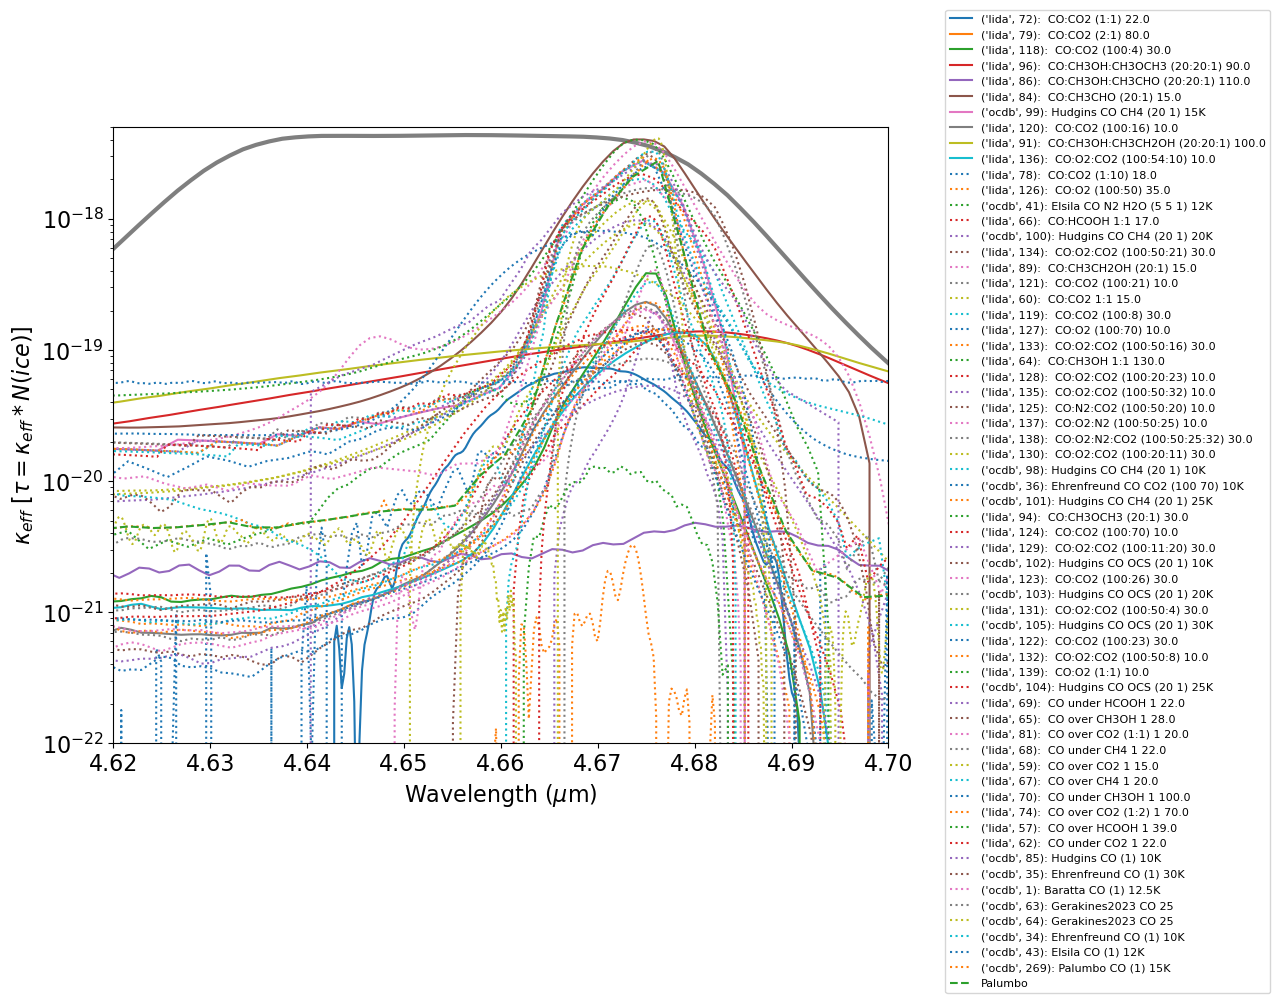

In [20]:
for ii, (key, tb) in enumerate(cotbs.items()):
    #if key in (('ocdb', 64), ('ocdb', 63)):
        # bad - temporary
        #continue
    kk = tb['k₁'] if 'k₁' in tb.colnames else tb['k']
    raise TODO not 28 daltons for all these dudes
    opacity = ((kk.quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (28*u.Da)))).to(u.cm**2)
    pl.plot(tb['Wavelength'], 
            opacity,
            label=f'{key}: {tb.meta["author"]} {tb.meta["composition"]} {tb.meta["temperature"]}'
                    if 'author' in tb.meta else
                  f'{key}: {tb.meta["index"]} {tb.meta["molecule"]} {tb.meta["ratio"]} {tb.meta["temperature"]}',
            linestyle='-' if ii<10 else ':')
pl.plot(palumbo['Wavelength'],
        (palumbo['k']* palumbo['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (28*u.Da))).to(u.cm**2),
        linestyle='--',
        label='Palumbo')

_, ymax = pl.ylim()
xarr = wavelength_table_466['Wavelength'].quantity.to(u.um)
pl.plot(xarr, wavelength_table_466['Transmission']/wavelength_table_466['Transmission'].max() * ymax,
        color='k', linewidth=3, alpha=0.5, zorder=-5)

pl.semilogy();
pl.ylim(1e-22, 5e-18);

pl.legend(loc='upper right', bbox_to_anchor=(1,1,0.5,0.2,), fontsize=8);
pl.xlim(4.62, 4.70);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");

## CO at 4.1

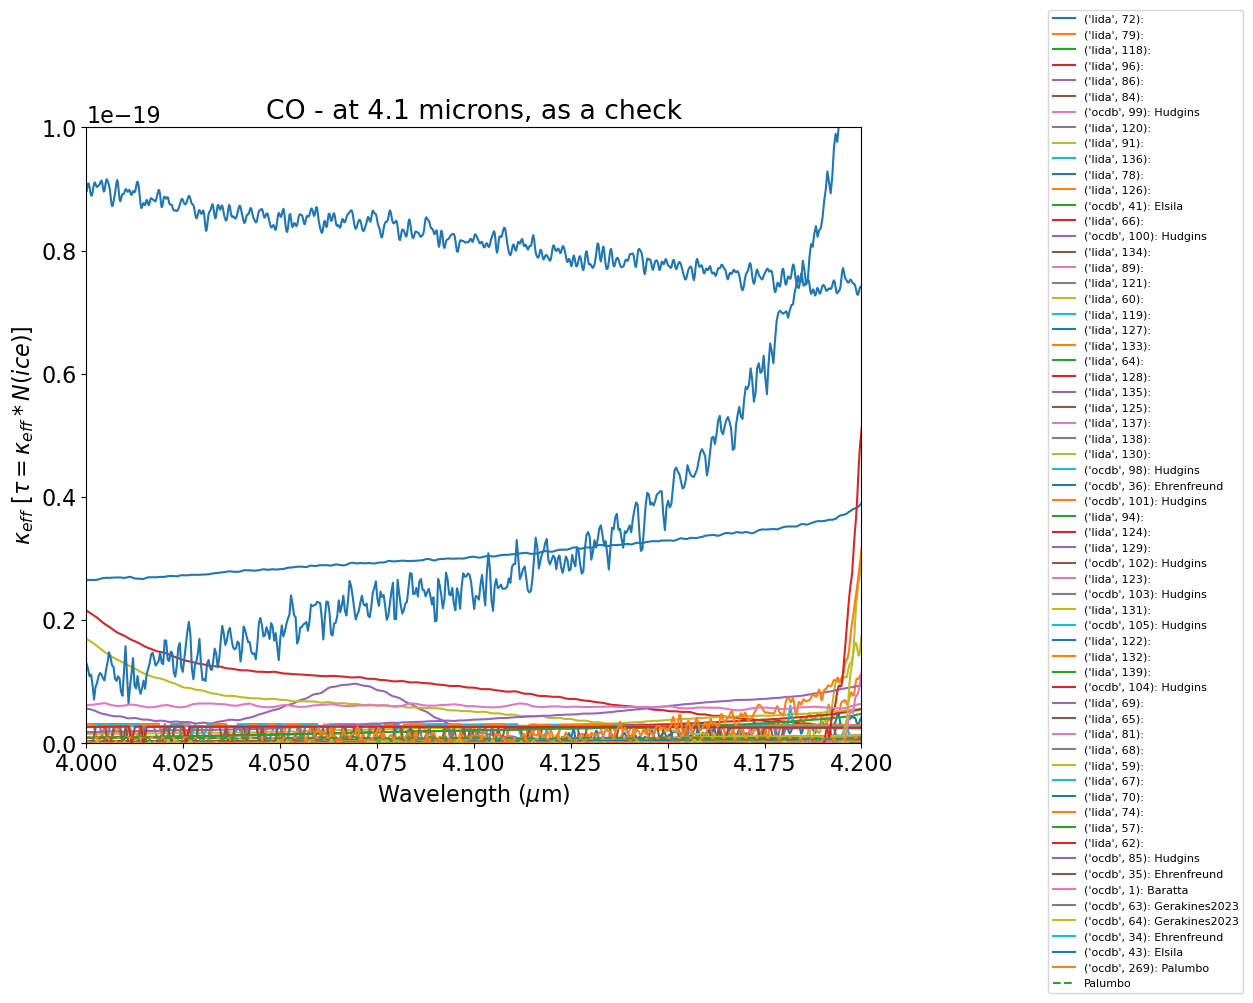

In [21]:
for key, tb in cotbs.items():
    if key in (64, 63):
        # bad - temporary
        continue
    pl.plot(tb['Wavelength'], 
            ((tb['k₁'].quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (28*u.Da)))).to(u.cm**2),
            label=f'{key}: {tb.meta["author"]}')
pl.plot(palumbo['Wavelength'],
        (palumbo['k'].quantity* palumbo['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (28*u.Da))).to(u.cm**2),
        linestyle='--',
        label='Palumbo')
pl.legend(loc='upper right', bbox_to_anchor=(1,1,0.5,0.2), fontsize=8);
pl.xlim(4.00, 4.20);
pl.ylim(0, 1e-19)
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("CO - at 4.1 microns, as a check");

In [22]:
tb.colnames

['Wavenumber (cm⁻¹)',
 'n₁',
 'Dn₁  (+/-)',
 'k₁',
 'Dk₁  (+/-)',
 'col5',
 'Wavelength',
 'k']

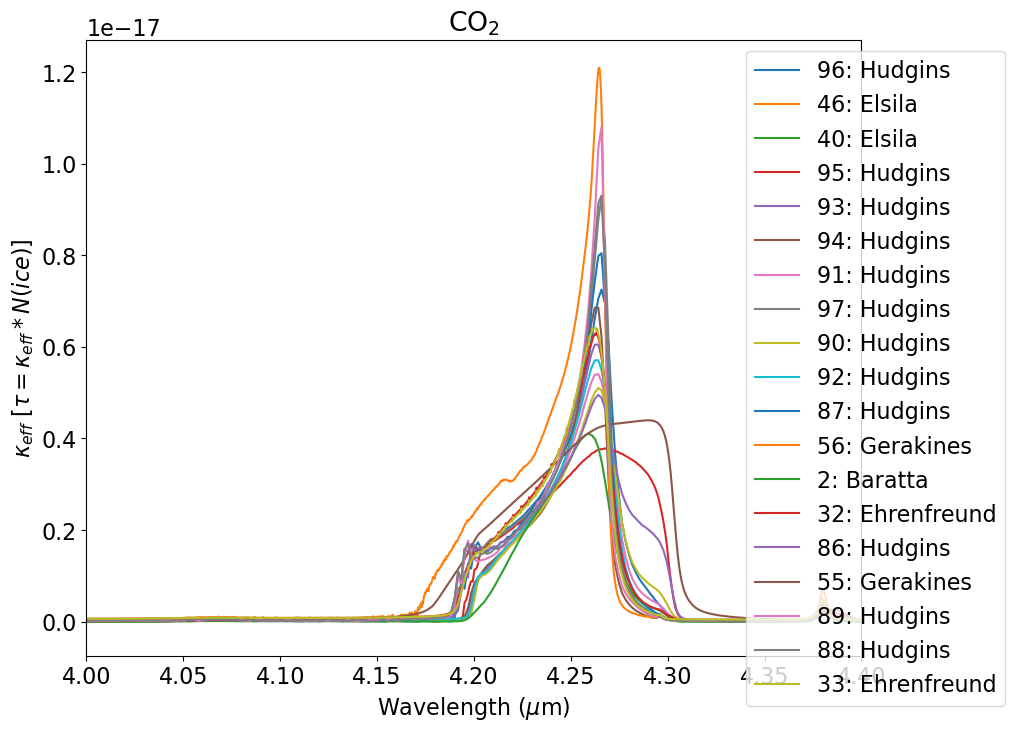

In [23]:
for key, tb in co2tbs.items():
    if key in (64, 63):
        # bad - temporary
        continue
    if 'k₁' in tb.colnames:
        pl.plot(tb['Wavelength'], 
                ((tb['k₁'].quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (44*u.Da)))).to(u.cm**2),
                label=f'{key}: {tb.meta["author"]}')
    else:
        print(f'{key} -> {tb.meta} failed - no k₁')
pl.legend(loc='upper right', bbox_to_anchor=(1,1,0.2,0));
pl.xlim(4.0, 4.40);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("CO$_2$");

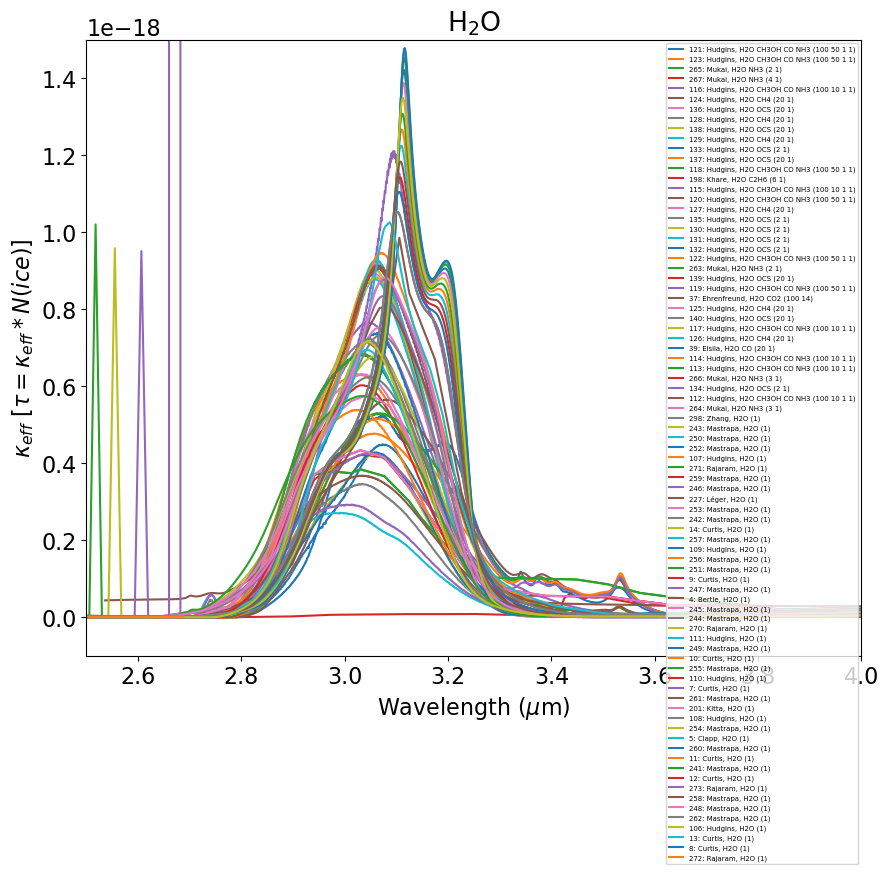

In [24]:
for key, tb in h2otbs.items():
    if key in (64, 63):
        # bad - temporary
        continue
    if 'k₁' in tb.colnames:
        pl.plot(tb['Wavelength'], 
                ((tb['k₁'].quantity * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (18*u.Da)))).to(u.cm**2),
                label=f'{key}: {tb.meta["author"]}, {tb.meta["composition"]}')
    else:
        print(f'{key} -> {tb.meta} failed - no k₁')
pl.legend(loc='best', fontsize=5);
pl.xlim(2.50, 4.00);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("H$_2$O");
pl.ylim(-1e-19, 1.5e-18);

# Make absorbance -> N tables

In [43]:
import icemodels
imp.reload(icemodels.core)
imp.reload(icemodels)
from icemodels import absorbed_spectrum, absorbed_spectrum_Gaussians, convsum, fluxes_in_filters, load_molecule, load_molecule_ocdb, atmo_model, molecule_data
from icemodels.core import composition_to_molweight

In [26]:
from astroquery.svo_fps import SvoFps

In [27]:
jfilts = SvoFps.get_filter_list('JWST')
jfilts.add_index('filterID')

In [28]:
#filterid = 'JWST/NIRCam.F466N'
#xarr = np.linspace(filter_data.loc[filterid]['WavelengthMin'] * u.AA,
#                   filter_data.loc[filterid]['WavelengthMax'] * u.AA,
#                   1000)
xarr = np.linspace(3.1*u.um, 4.9*u.um, 10000)
phx4000 = atmo_model(4000, xarr=xarr)

In [29]:
tb.meta

OrderedDict([('density', <Quantity 1. g / cm3>),
             ('reference', 'Rajaram et al. (2001)'),
             ('doi', 'doi https //doi.org/10.1364/AO.40.004449'),
             ('composition', 'H2O (1)'),
             ('temperature', '186K'),
             ('ocdb page', 'https //ocdb.smce.nasa.gov/dataset/272'),
             ('author', 'Rajaram'),
             ('molecule', 'H2O')])

In [30]:
for mol, tbs in {'H2O': h2otbs, 'CO': cotbs, 'CO2': co2tbs}.items():
    for tb in tbs.values():
        if 'k₁' in tb.colnames:
            tb['k'] = tb['k₁']
        else:
            print(f'{key} -> {tb.meta} had no k₁')

In [31]:
from astropy.table import Table
import time

## Calculate dmags

In [32]:
molecule_data

{'ch3oh': {'url': 'https://raw.githubusercontent.com/willastro/ifw_miri_gto_pstars/main/nk/ch3oh-a-Gerakines2020.txt',
  'molwt': <Quantity 32. u>},
 'co2': {'url': 'https://raw.githubusercontent.com/willastro/ifw_miri_gto_pstars/main/nk/co2-a-Gerakines2020.txt',
  'molwt': <Quantity 44. u>},
 'ch4': {'url': 'https://raw.githubusercontent.com/willastro/ifw_miri_gto_pstars/main/nk/ch4-a-Gerakines2020.txt',
  'molwt': <Quantity 16. u>},
 'co': {'url': 'https://raw.githubusercontent.com/willastro/ifw_miri_gto_pstars/main/nk/co-a-Palumbo2006.txt',
  'molwt': <Quantity 28. u>},
 'h2o': {'url': 'https://raw.githubusercontent.com/willastro/ifw_miri_gto_pstars/main/nk/h2o-a-Hudgins1993.txt',
  'molwt': <Quantity 18. u>},
 'h2o_b': {'url': 'https://raw.githubusercontent.com/willastro/ifw_miri_gto_pstars/main/nk/h2o_Rocha.txt',
  'molwt': <Quantity 18. u>},
 'nh3': {'url': 'https://raw.githubusercontent.com/willastro/ifw_miri_gto_pstars/main/nk/nh3_Roser_2021.txt',
  'molwt': <Quantity 17. u>,
 

In [33]:
cotbs[('ocdb', 104)].meta

OrderedDict([('density', <Quantity 1. g / cm3>),
             ('reference', 'Hudgins et al. (1993)'),
             ('doi', 'doi https //doi.org/10.1086/191796'),
             ('composition', 'CO OCS (20 1)'),
             ('temperature', '25K'),
             ('ocdb page', 'https //ocdb.smce.nasa.gov/dataset/104'),
             ('author', 'Hudgins'),
             ('molecule', 'CO')])

In [34]:
raise TODO: Calculate molecular weights so we can fairly compare the ices

...probably can just keep assuming 1 g/cm^3?

SyntaxError: invalid syntax (3853053118.py, line 1)

In [35]:
%pip install molmass

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 3.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [53]:
import re
from molmass import Formula
compstr =  'CO:CH3OH:CH3OCH3 (20:20:1)'
mols, comps = compstr.split(" (")
print(mols, re.split("[: ]", mols))
print(comps)
comps = map(int, comps.strip(")").split(":"))
molvals = [Formula(mol).mass for mol in re.split("[: ]", mols)]

CO:CH3OH:CH3OCH3 ['CO', 'CH3OH', 'CH3OCH3']
20:20:1)


In [70]:
import molmass
xarr = phx4000['nu'].quantity.to(u.um, u.spectral())
cols = np.geomspace(1e15, 1e22, 25)

for mol, tbs in {'H2O': h2otbs, 'CO': cotbs, 'CO2': co2tbs}.items():
    dmag_rows = []
    
    for key, consts in tbs.items():

        if 'k' not in consts.colnames:
            print(f"Molecule {mol} with key {key} failed with no opacities")
            continue
        
        dmags410 = []
        dmags466 = []
        dmags444 = []
        dmags356 = []
        dmags405 = []
    
        molecule = mol.lower()
        molwt = u.Quantity(composition_to_molweight(consts.meta['composition']), u.Da)

        tt0 = time.time()
        print(molecule, key, end=":  ")
        #print(f"  column,   mag410,  mag410*,  mag466n, mag466n*, dmag410, dmag466")
        for col in cols:
            t0 = time.time()
            spec = absorbed_spectrum(col*u.cm**-2, consts, molecular_weight=molwt,
                                      spectrum=phx4000['fnu'].quantity,
                                      xarr=xarr,
                                     )
            t1 = time.time()
            cmd_x = ('JWST/NIRCam.F410M', 'JWST/NIRCam.F466N', 'JWST/NIRCam.F356W', 'JWST/NIRCam.F444W',  'JWST/NIRCam.F405N')
            flxd_ref = fluxes_in_filters(xarr, phx4000['fnu'].quantity, filterids=cmd_x)
            t2 = time.time()
            flxd = fluxes_in_filters(xarr, spec, filterids=cmd_x)
            t3 = time.time()
            mags_x_star = (-2.5*np.log10(flxd_ref[cmd_x[0]] / u.Quantity(jfilts.loc[cmd_x[0]]['ZeroPoint'], u.Jy)),
                           -2.5*np.log10(flxd_ref[cmd_x[1]] / u.Quantity(jfilts.loc[cmd_x[1]]['ZeroPoint'], u.Jy)),
                           -2.5*np.log10(flxd_ref[cmd_x[2]] / u.Quantity(jfilts.loc[cmd_x[2]]['ZeroPoint'], u.Jy)),
                           -2.5*np.log10(flxd_ref[cmd_x[3]] / u.Quantity(jfilts.loc[cmd_x[3]]['ZeroPoint'], u.Jy)),
                           -2.5*np.log10(flxd_ref[cmd_x[4]] / u.Quantity(jfilts.loc[cmd_x[4]]['ZeroPoint'], u.Jy)),
                          )
            mags_x = (-2.5*np.log10(flxd[cmd_x[0]] / u.Quantity(jfilts.loc[cmd_x[0]]['ZeroPoint'], u.Jy)),
                      -2.5*np.log10(flxd[cmd_x[1]] / u.Quantity(jfilts.loc[cmd_x[1]]['ZeroPoint'], u.Jy)),
                      -2.5*np.log10(flxd[cmd_x[2]] / u.Quantity(jfilts.loc[cmd_x[2]]['ZeroPoint'], u.Jy)),
                      -2.5*np.log10(flxd[cmd_x[3]] / u.Quantity(jfilts.loc[cmd_x[3]]['ZeroPoint'], u.Jy)),
                      -2.5*np.log10(flxd[cmd_x[4]] / u.Quantity(jfilts.loc[cmd_x[4]]['ZeroPoint'], u.Jy)),
                     )
            dmags405.append(mags_x[4]-mags_x_star[4])
            dmags444.append(mags_x[3]-mags_x_star[3])
            dmags356.append(mags_x[2]-mags_x_star[2])
            dmags466.append(mags_x[1]-mags_x_star[1])
            dmags410.append(mags_x[0]-mags_x_star[0])
            # why would f410m change at all?
            #print(f"{col:8.1g}, {mags_x[0]:8.1f}, {mags_x_star[0]:8.1f}, {mags_x[1]:8.1f}, {mags_x_star[1]:8.1f}, {dmags410[-1]:8.1f}, {dmags466[-1]:8.1f}")
            try:
                database, mol_id = key
            except TypeError:
                mol_id = key
                database = 'ocdb'
            dmag_rows.append({'molecule': molecule, 'mol_id': mol_id, 'database': database, 'column': col, 'F356W': dmags356[-1], 'F410M': dmags410[-1],
                              'F444W': dmags444[-1], 'F466N': dmags466[-1], 'F405N': dmags405[-1]})
            t4 = time.time()
            #print(f"col={col:0.1g}; Steps took {t1-t0:0.1g}, {t2-t1:0.1g}, {t3-t2:0.1g}, {t4-t3:0.1g}")
        tt1 = time.time()
        print(f"Done with {molecule} {key}; dt={tt1-tt0:0.3g}")
    dmag_tbl = Table(dmag_rows)
    dmag_tbl.write(f'{basepath}/tables/{mol}_ice_absorption_tables.ecsv', overwrite=True)
    dmag_tbl.add_index('database')
    dmag_tbl.add_index('mol_id')
    dmag_tbl

h2o 121:  Done with h2o 121; dt=2.95
h2o 123:  Done with h2o 123; dt=1.58
h2o 265:  Done with h2o 265; dt=1.39
h2o 267:  Done with h2o 267; dt=1.36
h2o 116:  Done with h2o 116; dt=1.35
h2o 124:  Done with h2o 124; dt=1.35
h2o 136:  Done with h2o 136; dt=1.35
h2o 128:  Done with h2o 128; dt=1.35
h2o 138:  Done with h2o 138; dt=1.43
h2o 129:  Done with h2o 129; dt=1.35
h2o 133:  Done with h2o 133; dt=1.35
h2o 137:  Done with h2o 137; dt=1.36
h2o 118:  Done with h2o 118; dt=1.53
h2o 198:  Done with h2o 198; dt=1.34
h2o 115:  Done with h2o 115; dt=1.35
h2o 120:  Done with h2o 120; dt=1.37
h2o 127:  Done with h2o 127; dt=1.41
h2o 135:  Done with h2o 135; dt=1.36
h2o 130:  Done with h2o 130; dt=1.35
h2o 131:  Done with h2o 131; dt=1.35
h2o 132:  Done with h2o 132; dt=1.35
h2o 122:  Done with h2o 122; dt=1.35
h2o 263:  Done with h2o 263; dt=1.35
h2o 139:  Done with h2o 139; dt=1.53
h2o 119:  Done with h2o 119; dt=1.35
h2o 37:  Done with h2o 37; dt=1.35
h2o 125:  Done with h2o 125; dt=1.35
h2o

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Done with h2o 14; dt=1.36
h2o 257:  Done with h2o 257; dt=1.36
h2o 109:  Done with h2o 109; dt=1.36
h2o 256:  Done with h2o 256; dt=1.36
h2o 251:  Done with h2o 251; dt=1.36
h2o 9:  Done with h2o 9; dt=1.36
h2o 247:  Done with h2o 247; dt=1.36
h2o 4:  Done with h2o 4; dt=1.54
h2o 245:  Done with h2o 245; dt=1.35
h2o 244:  Done with h2o 244; dt=1.36
h2o 270:  Done with h2o 270; dt=1.36
h2o 111:  Done with h2o 111; dt=1.36
h2o 249:  Done with h2o 249; dt=1.36
h2o 10:  Done with h2o 10; dt=1.35
h2o 255:  Done with h2o 255; dt=1.36
h2o 110:  Done with h2o 110; dt=1.35
h2o 7:  Done with h2o 7; dt=1.35
h2o 261:  Done with h2o 261; dt=1.36
h2o 201:  Done with h2o 201; dt=1.54
h2o 108:  Done with h2o 108; dt=1.35
h2o 254:  Done with h2o 254; dt=1.36
h2o 5:  Done with h2o 5; dt=1.36
h2o 260:  Done with h2o 260; dt=1.36
h2o 11:  Done with h2o 11; dt=1.35
h2o 241:  Done with h2o 241; dt=1.36
h2o 12:  Done with h2o 12; dt=1.35
h2o 273:  Done with h2o 273; dt=1.35
h2o 258:  Done with h2o 258; dt=1.

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Done with co ('lida', 70); dt=1.35
co ('lida', 74):  Done with co ('lida', 74); dt=1.36
co ('lida', 57):  Done with co ('lida', 57); dt=1.35
co ('lida', 62):  Done with co ('lida', 62); dt=1.36
co ('ocdb', 85):  Done with co ('ocdb', 85); dt=1.35
co ('ocdb', 35):  Done with co ('ocdb', 35); dt=1.35
co ('ocdb', 1):  Done with co ('ocdb', 1); dt=1.35
co ('ocdb', 63):  Done with co ('ocdb', 63); dt=1.35
co ('ocdb', 64):  Done with co ('ocdb', 64); dt=1.35
co ('ocdb', 34):  Done with co ('ocdb', 34); dt=1.53
co ('ocdb', 43):  Done with co ('ocdb', 43); dt=1.33
co ('ocdb', 269):  Done with co ('ocdb', 269); dt=1.34
co2 96:  Done with co2 96; dt=1.35
co2 46:  Done with co2 46; dt=1.35
co2 40:  Done with co2 40; dt=1.35
co2 95:  Done with co2 95; dt=1.35
co2 93:  Done with co2 93; dt=1.36
co2 94:  Done with co2 94; dt=1.35
co2 91:  Done with co2 91; dt=1.35
co2 97:  Done with co2 97; dt=1.35
co2 90:  Done with co2 90; dt=1.54
co2 92:  Done with co2 92; dt=1.33
co2 87:  Done with co2 87; dt=1.

## column vs dmag plots

ocdb, 64;  ocdb, 1;  ocdb, 98;  ocdb, 99;  ocdb, 100;  ocdb, 36;  ocdb, 101;  ocdb, 102;  ocdb, 103;  ocdb, 41;  ocdb, 105;  ocdb, 104;  ocdb, 35;  ocdb, 34;  ocdb, 43;  ocdb, 269;  ocdb, 85;  ocdb, 63;  lida, 128;  lida, 129;  lida, 130;  lida, 131;  lida, 132;  lida, 133;  lida, 134;  lida, 135;  lida, 136;  lida, 137;  lida, 138;  lida, 139;  lida, 57;  lida, 59;  lida, 60;  lida, 62;  lida, 64;  lida, 65;  lida, 66;  lida, 67;  lida, 68;  lida, 69;  lida, 70;  lida, 72;  lida, 74;  lida, 78;  lida, 79;  lida, 81;  lida, 84;  lida, 86;  lida, 89;  lida, 91;  lida, 94;  lida, 96;  lida, 118;  lida, 119;  lida, 120;  lida, 121;  lida, 122;  lida, 123;  lida, 124;  lida, 125;  lida, 126;  lida, 127;  

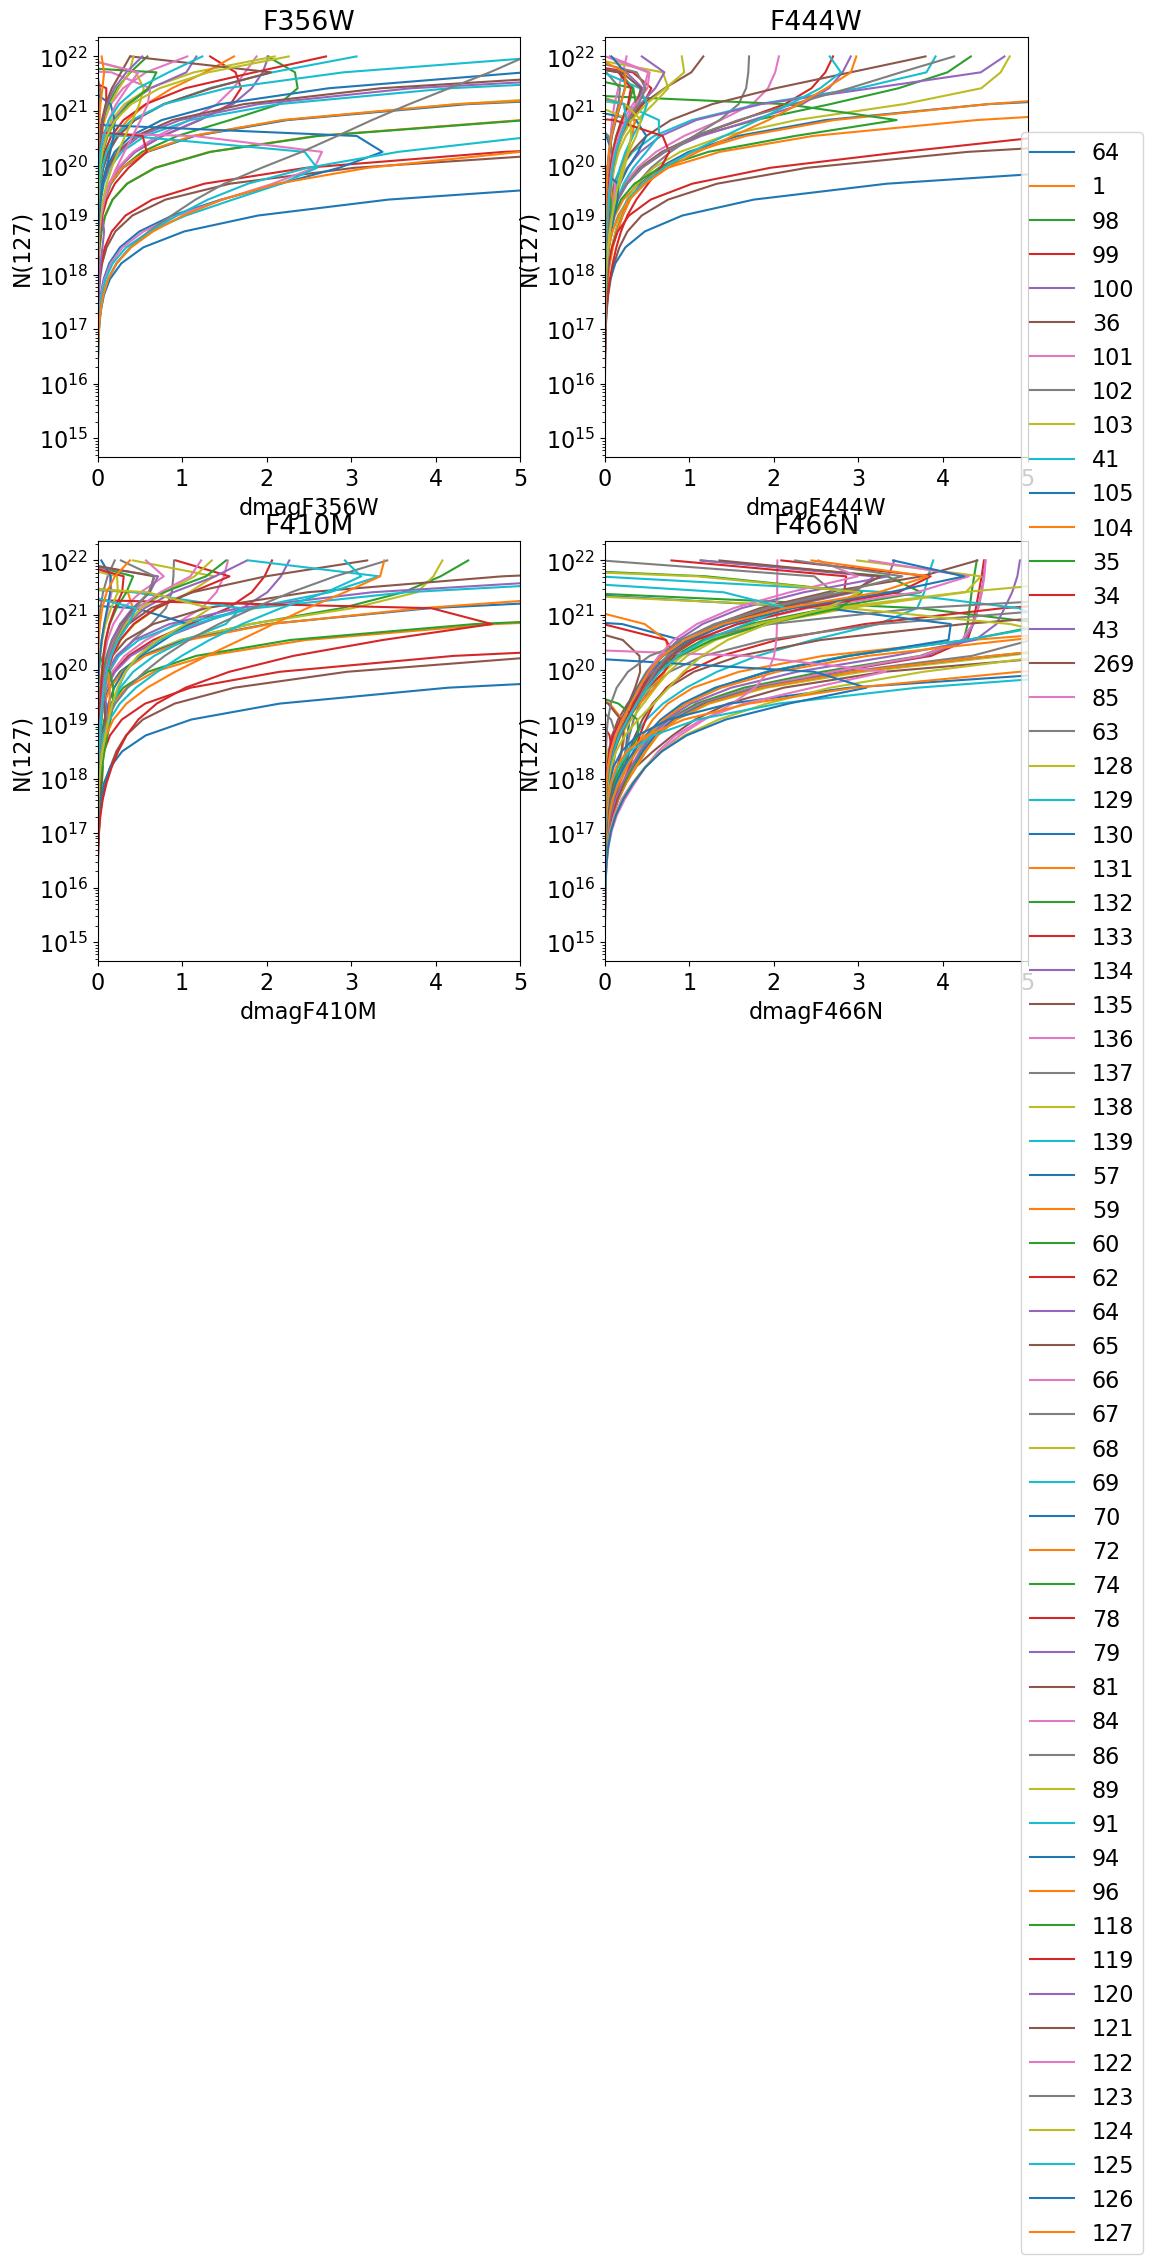

In [329]:
dmag_tbl.add_index('database')
dmag_tbl.add_index('mol_id')
fig = pl.figure(figsize=(12,12))
for database in ('ocdb', 'lida'):
    if database in dmag_tbl['database']:
        for mol_id in set(dmag_tbl.loc[('database', database)]['mol_id']):
            print(f'{database}, {mol_id}', end=';  ')
            row = dmag_tbl.loc[('database', database)].loc[('mol_id', mol_id)]
            cols = row['column']
            for ii, filtername in enumerate(['F356W', 'F444W', 'F410M', 'F466N',]):
                pl.subplot(2, 2, ii+1).semilogy(row[filtername], cols, label=mol_id)
                pl.xlim(0,5);
                pl.title(filtername)
                pl.xlabel(f"dmag{filtername}")
                pl.ylabel(f"N({mol_id})")
pl.legend(loc='upper right', bbox_to_anchor=(1,1,0.3,1));

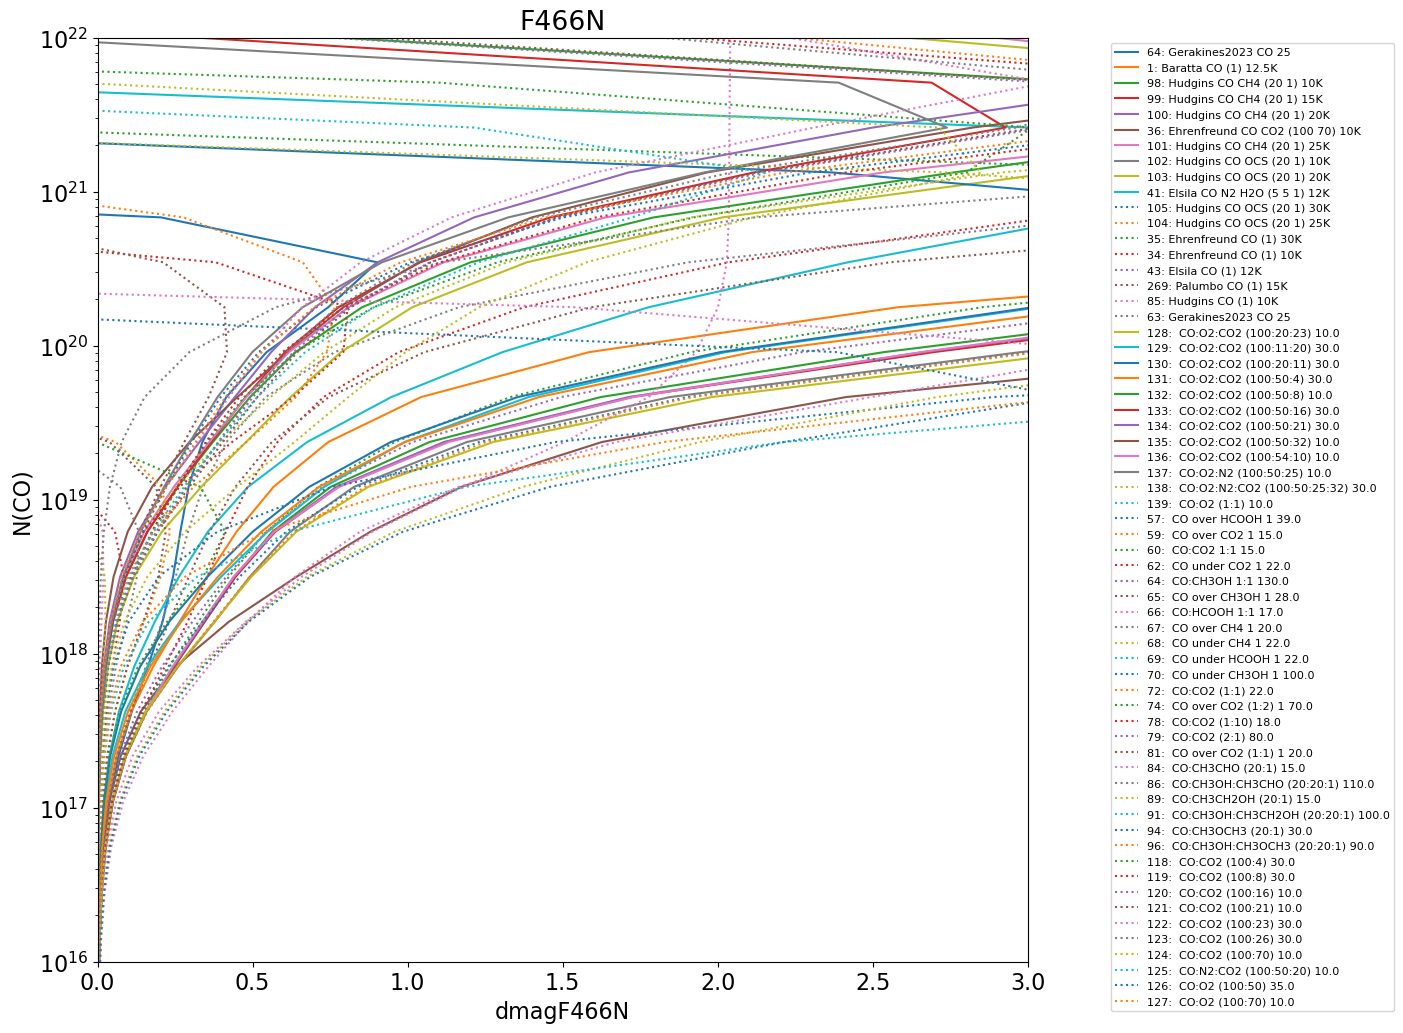

In [330]:
dmag_tbl = Table.read(f'{basepath}/tables/CO_ice_absorption_tables.ecsv')

dmag_tbl.add_index('database')
dmag_tbl.add_index('mol_id')

fig = pl.figure(figsize=(12,12))
for database in set(dmag_tbl['database']):
    db_dmag_tbl = dmag_tbl.loc[('database', database)]
    for ii, mol_id in enumerate(set(db_dmag_tbl['mol_id'])):
        row = dmag_tbl.loc[('database', database)].loc[('mol_id', mol_id)]
        cols = row['column']
        filtername = 'F466N'
        tb = cotbs[(database, mol_id)]
        pl.semilogy(row[filtername], cols,
                label=f'{mol_id}: {tb.meta["author"]} {tb.meta["composition"]} {tb.meta["temperature"]}', linestyle='-' if ii<10 else ':')
        pl.xlim(0,3);
        pl.ylim(1e16, 1e22);
        pl.title(filtername)
        pl.xlabel(f"dmag{filtername}")
        pl.ylabel(f"N(CO)")
pl.legend(loc='upper right', bbox_to_anchor=(1,1,0.4,0), fontsize=8);

In [331]:
mol_id

127

In [332]:
ls /blue/adamginsburg/adamginsburg/jwst/brick//tables/

AV_vs_CO_table.ecsv             CO_ice_absorption_tables.ecsv
CO2_ice_absorption_tables.ecsv  H2O_ice_absorption_tables.ecsv


In [333]:
set(dmag_tbl['molecule'])

{'co'}

# Gerakines - direct from paper

In [334]:
import icemodels
imp.reload(icemodels.core)
imp.reload(icemodels)
from icemodels.core import absorbed_spectrum, absorbed_spectrum_Gaussians, convsum, fluxes_in_filters, load_molecule, load_molecule_ocdb, atmo_model, molecule_data, retrieve_gerakines_co

In [335]:
gerakines = retrieve_gerakines_co()

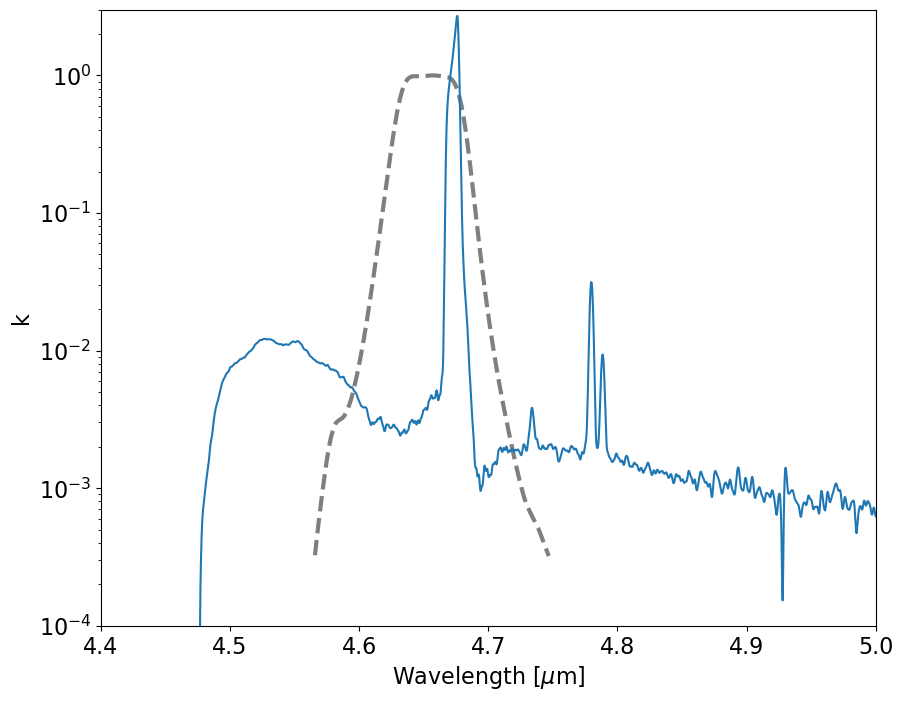

In [336]:
wavelength = gerakines['Wavelength']
pl.semilogy(wavelength, gerakines['k'])
pl.xlim(4.4, 5.0);
pl.ylim(1e-4, 3);
pl.xlabel("Wavelength [$\\mu$m]")
pl.ylabel("k");


_, ymax = pl.ylim()
xarr = wavelength_table_466['Wavelength'].quantity.to(u.um)
pl.plot(xarr, wavelength_table_466['Transmission']/wavelength_table_466['Transmission'].max(),
        color='k', linewidth=3, alpha=0.5, zorder=-5, linestyle='--');


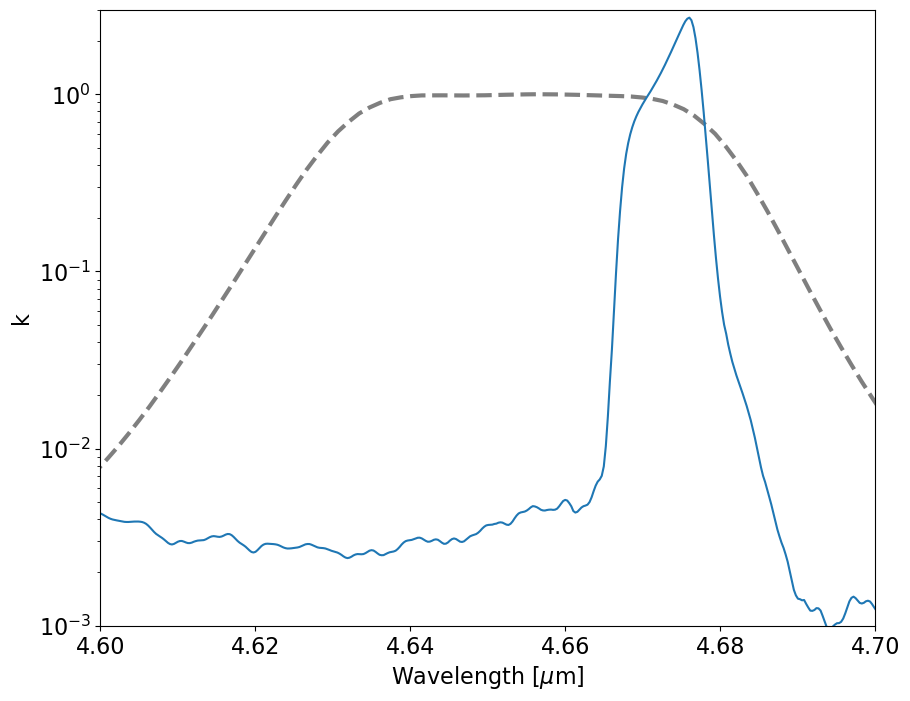

In [337]:
wavelength = gerakines['Wavelength']
pl.semilogy(wavelength, gerakines['k'])
pl.xlim(4.4, 5.0);
pl.ylim(1e-4, 3);
pl.xlabel("Wavelength [$\\mu$m]")
pl.ylabel("k");


_, ymax = pl.ylim()
xarr = wavelength_table_466['Wavelength'].quantity.to(u.um)
pl.plot(xarr, wavelength_table_466['Transmission']/wavelength_table_466['Transmission'].max(),
        color='k', linewidth=3, alpha=0.5, zorder=-5, linestyle='--');
pl.xlim(4.6, 4.7);
pl.ylim(1e-3,3);